# Mechanics Movement Implementations Analysis

This notebook compares three PhysiCell implementations of the same movement idea:

- `mechanics_movement`: one-step motility pulse with a warm start for `previous_velocity`
- `mechanics_movement_displacement`: same one-step motility pulse, but without the warm start
- `mechanics_movement_continuous`: direct velocity forcing through `custom_update_velocity` over a short time window

The notebook does two things:

1. compares the code paths used by each implementation
2. compares the observed motion in the saved outputs

For these runs, the saved `x_velocity` field is not always the best indicator of real movement. The most reliable signals are therefore:

- `x_position`
- per-frame displacement `delta_x`
- inferred speed `delta_x / delta_time`
- `migration_speed`, `is_motile`, and `x_motility_vector` as diagnostics

In [57]:
from pathlib import Path
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from pctk import multicellds

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)

In [ ]:
IMPLEMENTATIONS = [
    {
        'label': 'mechanics_movement',
        'display_name': 'Warm-start pulse',
        'results_folder': Path('../results/mechanics_movement'),
        'source_file': Path('../code/user_projects/mechanics_movement/custom_modules/custom.cpp'),
        'dt_mechanics': 0.1,
        'update_velocity_hook': 'standard_update_cell_velocity',
        'where_motion_is_defined': 'custom_function enables motility once and seeds previous_velocity.',
        'execution_summary': 'The first mechanics step builds a motility vector in +x and also initializes the velocity history used by the standard PhysiCell update.',
        'expected_difference': 'This is the reference one-step pulse. The warm start should change the first displacement relative to the displacement-only variant.',
    },
    {
        'label': 'mechanics_movement_displacement',
        'display_name': 'Pulse without warm start',
        'results_folder': Path('../results/mechanics_movement_displacement'),
        'source_file': Path('../code/user_projects/mechanics_movement_displacement/custom_modules/custom.cpp'),
        'dt_mechanics': 0.1,
        'update_velocity_hook': 'standard_update_cell_velocity',
        'where_motion_is_defined': 'custom_function enables motility once, but leaves previous_velocity at zero.',
        'execution_summary': 'The code still relies on the standard PhysiCell velocity update, but the first step starts without initialized velocity history.',
        'expected_difference': 'Only one line of execution logic changes, but it changes the first mechanics update and therefore the first observed displacement.',
    },
    {
        'label': 'mechanics_movement_continuous',
        'display_name': 'Direct velocity pulse',
        'results_folder': Path('../results/mechanics_movement_continuous'),
        'source_file': Path('../code/user_projects/mechanics_movement_continuous/custom_modules/custom.cpp'),
        'dt_mechanics': 0.1,
        'update_velocity_hook': 'custom_update_velocity',
        'where_motion_is_defined': 'custom_function toggles motility state, while custom_update_velocity directly overwrites pCell->velocity during a pulse window.',
        'execution_summary': 'Velocity is forced to +x for a finite interval, then reset to zero. Motion is no longer coming from the standard motility integrator.',
        'expected_difference': 'This changes both the execution pathway and the timing: the pulse lasts across multiple mechanics steps and uses a smaller dt_mechanics.',
    },
]

implementation_code_table = pd.DataFrame(IMPLEMENTATIONS)[
    ['display_name', 'update_velocity_hook', 'dt_mechanics', 'where_motion_is_defined', 'expected_difference']
]

In [62]:
def get_cell_row(cells_df: pd.DataFrame, cell_id: int = 0) -> pd.Series:
    if cell_id in cells_df.index:
        cell = cells_df.loc[cell_id]
    elif 'ID' in cells_df.columns:
        cell = cells_df.loc[cells_df['ID'] == cell_id].iloc[0]
    else:
        cell = cells_df.iloc[cell_id]

    if isinstance(cell, pd.DataFrame):
        cell = cell.iloc[0]

    return cell


def load_implementation_result(spec: dict, cell_id: int = 0) -> pd.DataFrame:
    reader = multicellds.MultiCellDS(output_folder=str(spec['results_folder']))
    xml_files = sorted(spec['results_folder'].glob('output*.xml'))
    frame_iterator = reader.cells_as_frames_iterator()
    rows = []

    for xml_path, (_, cells_df) in zip(xml_files, frame_iterator):
        tree = ET.parse(xml_path)
        time_min = float(tree.getroot().findtext('./metadata/current_time'))
        cell = get_cell_row(cells_df, cell_id=cell_id)

        rows.append(
            {
                'time_min': time_min,
                'cell_id': cell_id,
                'x_position': float(cell.get('x_position', np.nan)),
                'y_position': float(cell.get('y_position', np.nan)),
                'z_position': float(cell.get('z_position', np.nan)),
                'x_velocity': float(cell.get('x_velocity', np.nan)),
                'y_velocity': float(cell.get('y_velocity', np.nan)),
                'z_velocity': float(cell.get('z_velocity', np.nan)),
                'migration_speed': float(cell.get('migration_speed', np.nan)),
                'is_motile': float(cell.get('is_motile', np.nan)),
                'x_motility_vector': float(cell.get('x_motility_vector', np.nan)),
                'y_motility_vector': float(cell.get('y_motility_vector', np.nan)),
                'z_motility_vector': float(cell.get('z_motility_vector', np.nan)),
            }
        )

    df = pd.DataFrame(rows).sort_values('time_min').reset_index(drop=True)
    df['delta_time'] = df['time_min'].diff()
    df['delta_x'] = df['x_position'].diff().fillna(0.0)
    df['inferred_x_speed'] = df['delta_x'] / df['delta_time']
    df['saved_speed_magnitude'] = np.sqrt(
        df[['x_velocity', 'y_velocity', 'z_velocity']].fillna(0.0).pow(2).sum(axis=1)
    )
    df['motility_vector_magnitude'] = np.sqrt(
        df[['x_motility_vector', 'y_motility_vector', 'z_motility_vector']].fillna(0.0).pow(2).sum(axis=1)
    )
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df


def first_nonzero_index(series: pd.Series, tol: float = 1e-12):
    matches = series.index[series.fillna(0.0).abs() > tol]
    return int(matches[0]) if len(matches) else None


def format_time_window(times: pd.Series) -> str:
    if times.empty:
        return 'not visible in saved frames'
    return f"{times.min():.3f} to {times.max():.3f} min"


def summarize_implementation(spec: dict, df: pd.DataFrame) -> dict:
    first_motion_idx = first_nonzero_index(df['delta_x'])
    motile_mask = (df['migration_speed'].fillna(0.0) > 0.0) | (df['is_motile'].fillna(0.0) > 0.5)
    motion_mask = df['delta_x'].fillna(0.0).abs() > 1e-12

    saved_state_window = format_time_window(df.loc[motile_mask, 'time_min'])
    motion_window = format_time_window(df.loc[motion_mask, 'time_min'])

    return {
        'label': spec['label'],
        'display_name': spec['display_name'],
        'hook': spec['update_velocity_hook'],
        'dt_mechanics': spec['dt_mechanics'],
        'first_motion_time_min': np.nan if first_motion_idx is None else float(df.loc[first_motion_idx, 'time_min']),
        'first_nonzero_delta_x_um': np.nan if first_motion_idx is None else float(df.loc[first_motion_idx, 'delta_x']),
        'max_x_position_um': float(df['x_position'].max()),
        'motion_steps': int(motion_mask.sum()),
        'motion_window_from_position': motion_window,
        'saved_state_window': saved_state_window,
        'saved_state_matches_motion': bool(saved_state_window == motion_window),
    }


def format_metric_axis(ax, title: str, ylabel: str):
    ax.set_title(title)
    ax.set_xlabel('Time (min)')
    ax.set_ylabel(ylabel)
    ax.legend()


def plot_metric(ax, results: dict, column: str, title: str, ylabel: str):
    style_map = {
        'mechanics_movement': {
            'alpha': 1.0,
            'zorder': 4,
            'linewidth': 3.0,
            'linestyle': '-',
            'marker': 'o',
            'markersize': 7,
            'markerfacecolor': 'none',
            'markeredgewidth': 1.8,
        },
        'mechanics_movement_displacement': {
            'alpha': 0.55,
            'zorder': 2,
            'linewidth': 2.0,
            'linestyle': '--',
            'marker': 'o',
            'markersize': 4,
        },
        'mechanics_movement_continuous': {
            'alpha': 0.45,
            'zorder': 1,
            'linewidth': 2.0,
            'linestyle': ':',
            'marker': 'o',
            'markersize': 4,
        },
    }

    for spec in IMPLEMENTATIONS:
        df = results[spec['label']]
        style = style_map.get(spec['label'], {'alpha': 0.8, 'zorder': 1, 'linewidth': 2.0, 'linestyle': '-', 'marker': 'o', 'markersize': 5})
        ax.plot(
            df['time_min'],
            df[column],
            linewidth=style['linewidth'],
            linestyle=style['linestyle'],
            marker=style['marker'],
            markersize=style['markersize'],
            alpha=style['alpha'],
            zorder=style['zorder'],
            label=spec['display_name'],
            markerfacecolor=style.get('markerfacecolor', None),
            markeredgewidth=style.get('markeredgewidth', None),
        )

    format_metric_axis(ax, title, ylabel)


def plot_comparison_dashboard(results: dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    metric_specs = [
        ('x_position', 'Observed X Position', 'X position (micron)'),
        ('migration_speed', 'Saved Migration Speed', 'Migration speed (micron / min)'),
    ]

    for ax, (column, title, ylabel) in zip(axes, metric_specs):
        plot_metric(ax, results, column, title, ylabel)

    plt.show()


def build_execution_markdown(implementations: list[dict], results: dict, summary_df: pd.DataFrame) -> str:
    summary_lookup = summary_df.set_index('label')
    lines = [
        '## Execution-Level Interpretation',
        '',
        'Below, each explanation connects the callback logic to what the saved frames actually show.',
        '',
    ]

    for spec in implementations:
        df = results[spec['label']]
        summary = summary_lookup.loc[spec['label']]
        peak_saved_speed = df['migration_speed'].fillna(0.0).max()
        peak_inferred_speed = df['inferred_x_speed'].fillna(0.0).max()

        if spec['label'] == 'mechanics_movement':
            explanation = (
                'This implementation injects a one-step motility pulse and also seeds the previous velocity term. '
                'Because `standard_update_cell_velocity` uses that seeded history, the first saved step already contains real displacement.'
            )
        elif spec['label'] == 'mechanics_movement_displacement':
            explanation = (
                'This version also applies the pulse in the standard motility pathway, but it does not warm-start the previous velocity state. '
                'As a result, the saved migration state can indicate motility before the position trace shows noticeable displacement.'
            )
        else:
            explanation = (
                'This version bypasses the standard motility update and writes directly to `pCell->velocity` inside `custom_update_velocity`. '
                'That produces a direct velocity pulse, so the saved trajectory shows an immediate, high-speed displacement during the pulse window.'
            )

        lines.extend(
            [
                f"### {spec['display_name']}",
                f"- Update hook: `{spec['update_velocity_hook']}`",
                f"- Mechanics time step: `{spec['dt_mechanics']}` min",
                f"- First visible motion in saved frames: `{summary['first_motion_time_min']}` min",
                f"- Peak observed x displacement per saved frame: `{summary['first_nonzero_delta_x_um']}` micron",
                f"- Peak saved migration speed: `{peak_saved_speed:.3f}` micron/min",
                f"- Peak inferred x speed from positions: `{peak_inferred_speed:.3f}` micron/min",
                f"- Motion visible from positions: `{summary['motion_window_from_position']}`",
                f"- Motility state visible in saved outputs: `{summary['saved_state_window']}`",
                f"- Interpretation: {explanation}",
                '',
            ]
        )

    return '\n'.join(lines)

In [60]:
results = {spec['label']: load_implementation_result(spec, cell_id=0) for spec in IMPLEMENTATIONS}

observed_summary = pd.DataFrame(
    [summarize_implementation(spec, results[spec['label']]) for spec in IMPLEMENTATIONS]
 )

display(Markdown('## Code-Level Comparison'))
display(implementation_code_table)

display(Markdown('## Observed Motion Summary'))
display(
    observed_summary[
        [
            'display_name',
            'hook',
            'dt_mechanics',
            'first_motion_time_min',
            'first_nonzero_delta_x_um',
            'max_x_position_um',
            'motion_steps',
            'motion_window_from_position',
            'saved_state_window',
            'saved_state_matches_motion',
        ]
    ]
 )

display(Markdown(build_execution_markdown(IMPLEMENTATIONS, results, observed_summary)))

## Code-Level Comparison

,display_name,update_velocity_hook,dt_mechanics,where_motion_is_defined,expected_difference
0,Warm-start pulse,standard_update_cell_velocity,0.10,custom_function enables motility once and seeds previous_velocity.,This is the reference one-step pulse. The warm start should change the first displacement relative to the displaceme...
1,Pulse without warm start,standard_update_cell_velocity,0.10,"custom_function enables motility once, but leaves previous_velocity at zero.","Only one line of execution logic changes, but it changes the first mechanics update and therefore the first observed..."
2,Direct velocity pulse,custom_update_velocity,0.05,"custom_function toggles motility state, while custom_update_velocity directly overwrites pCell->velocity during a pu...",This changes both the execution pathway and the timing: the pulse lasts across multiple mechanics steps and uses a s...


## Observed Motion Summary

,display_name,hook,dt_mechanics,first_motion_time_min,first_nonzero_delta_x_um,max_x_position_um,motion_steps,motion_window_from_position,saved_state_window,saved_state_matches_motion
0,Warm-start pulse,standard_update_cell_velocity,0.10,0.1,1.0,1.0,1,0.100 to 0.100 min,0.100 to 0.100 min,True
1,Pulse without warm start,standard_update_cell_velocity,0.10,0.1,1.5,1.5,1,0.100 to 0.100 min,0.100 to 0.100 min,True
2,Direct velocity pulse,custom_update_velocity,0.05,0.2,60.0,60.0,1,0.200 to 0.200 min,0.200 to 4.000 min,False


## What Executes Differently

For the first two implementations, the observed first-step difference is consistent with an Adams-Bashforth style history term. If the first position update uses $1.5 v_n - 0.5 v_{n-1}$, then seeding `previous_velocity = v_n` gives one step of displacement, while leaving `previous_velocity = 0` gives $1.5$ times that displacement.

### Warm-start pulse
- Velocity hook: `standard_update_cell_velocity`
- Code path: custom_function enables motility once and seeds previous_velocity.
- Execution meaning: The first mechanics step builds a motility vector in +x and also initializes the velocity history used by the standard PhysiCell update.
- Observed output: first non-zero displacement appears at t = 0.100 min with delta x = 1 micron.
- Motion seen in positions: 0.100 to 0.100 min; saved state remains active over: 0.100 to 0.100 min.
- Overall trajectory: maximum x position = 1 micron across 1 moving saved steps.

### Pulse without warm start
- Velocity hook: `standard_update_cell_velocity`
- Code path: custom_function enables motility once, but leaves previous_velocity at zero.
- Execution meaning: The code still relies on the standard PhysiCell velocity update, but the first step starts without initialized velocity history.
- Observed output: first non-zero displacement appears at t = 0.100 min with delta x = 1.5 micron.
- Motion seen in positions: 0.100 to 0.100 min; saved state remains active over: 0.100 to 0.100 min.
- Overall trajectory: maximum x position = 1.5 micron across 1 moving saved steps.
- Compared with the warm-start case: the first saved displacement is 1.5 times larger. This is the direct signature of leaving previous_velocity uninitialized for the first standard velocity update.

### Direct velocity pulse
- Velocity hook: `custom_update_velocity`
- Code path: custom_function toggles motility state, while custom_update_velocity directly overwrites pCell->velocity during a pulse window.
- Execution meaning: Velocity is forced to +x for a finite interval, then reset to zero. Motion is no longer coming from the standard motility integrator.
- Observed output: first non-zero displacement appears at t = 0.200 min with delta x = 60 micron.
- Motion seen in positions: 0.200 to 0.200 min; saved state remains active over: 0.200 to 4.000 min.
- Overall trajectory: maximum x position = 60 micron across 1 moving saved steps.
- Interpretation: this implementation changes the execution model entirely. The actual movement is visible in the position jump, but the saved migration state stays non-zero much longer than the motion itself, so the saved state variables are not a faithful proxy for executed motion here.

## Main Difference In Execution
- `mechanics_movement` and `mechanics_movement_displacement` execute through the same callback path; the only real difference is whether the history term `previous_velocity` is seeded before the first standard update.
- `mechanics_movement_continuous` uses a different execution pathway entirely: `custom_update_velocity` writes the velocity directly, `dt_mechanics` is smaller, and the motility state variables no longer track the realized movement as cleanly as the position data does.

## How To Read The Comparison

The tables above separate two questions:

- what each implementation writes in code
- what the saved outputs show after PhysiCell executes those callbacks

For this notebook, `delta_x` and `delta_x / delta_time` are the clearest indicators of real movement. They show the actual change in position between saved frames, which is exactly what you want when comparing execution behavior.

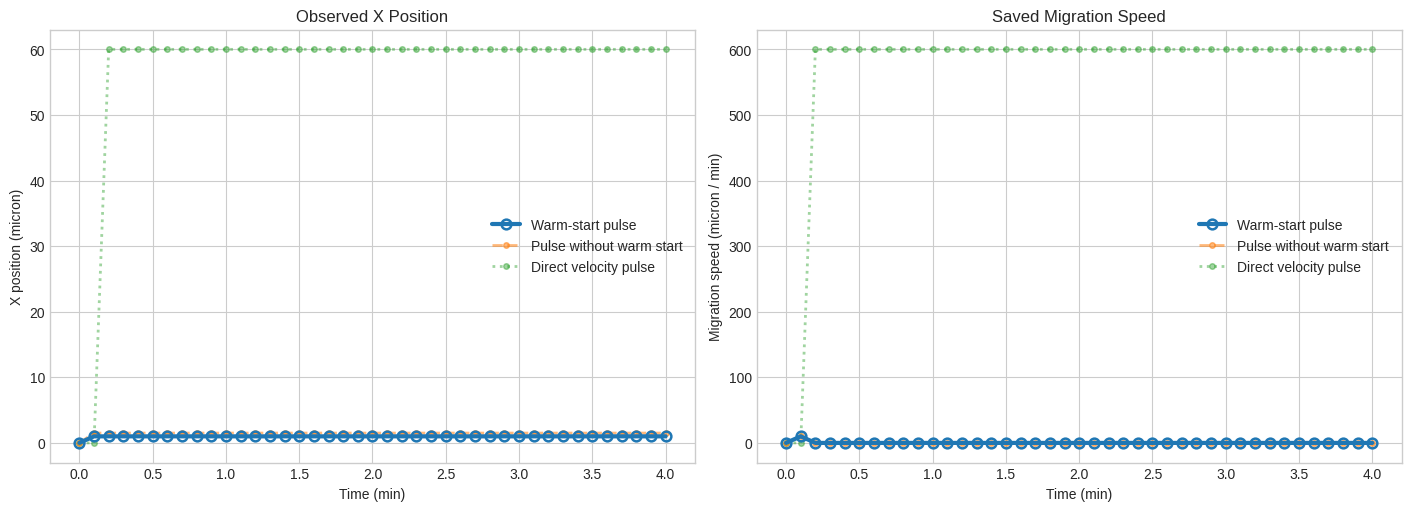

## Compact Frame-By-Frame View

,implementation,time_min,x_position,migration_speed
0,Warm-start pulse,0.0,0.0,0.0
1,Warm-start pulse,0.1,1.0,10.0
2,Warm-start pulse,0.2,1.0,0.0
3,Warm-start pulse,0.3,1.0,0.0
4,Warm-start pulse,0.4,1.0,0.0
...,...,...,...,...
118,Direct velocity pulse,3.6,60.0,600.0
119,Direct velocity pulse,3.7,60.0,600.0
120,Direct velocity pulse,3.8,60.0,600.0
121,Direct velocity pulse,3.9,60.0,600.0


In [63]:
plot_comparison_dashboard(results)

comparison_columns = [
    'time_min',
    'x_position',
    'migration_speed',
]

comparison_view = pd.concat(
    [
        results[spec['label']][comparison_columns].assign(implementation=spec['display_name'])
        for spec in IMPLEMENTATIONS
    ],
    ignore_index=True,
).loc[:, ['implementation', *comparison_columns]]

display(Markdown('## Compact Frame-By-Frame View'))
display(comparison_view.round(6))